### Load and Inspect Data Files

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load all relevant GTFS files
agency = pd.read_csv('agency.txt')
calendar = pd.read_csv('calendar.txt')
routes = pd.read_csv('routes.txt')
shapes = pd.read_csv('shapes.txt')
stop_times = pd.read_csv('stop_times.txt')
stops = pd.read_csv('stops.txt')
trips = pd.read_csv('trips.txt')

print("Agency:", agency.shape)
print("Calendar:", calendar.shape)
print("Routes:", routes.shape)
print("Shapes:", shapes.shape)
print("Stop Times:", stop_times.shape)
print("Stops:", stops.shape)
print("Trips:", trips.shape)


Agency: (1, 8)
Calendar: (3, 10)
Routes: (36, 12)
Shapes: (6643, 5)
Stop Times: (128434, 12)
Stops: (262, 6)
Trips: (5438, 10)


 ### Merge Trip, Route, Stop, and Stop Times Data also arrival time conversion to hours

In [53]:
# Merge: Trips + Stop Times → Link route_id to stop times
trip_stop_times = pd.merge(stop_times, trips, on="trip_id")

# Merge with Stops to get stop names and locations
full_df = pd.merge(trip_stop_times, stops, on="stop_id")

# Merge with Routes to get route names
full_df = pd.merge(full_df, routes, on="route_id")

# Convert arrival_time to hour
full_df['hour'] = pd.to_datetime(full_df['arrival_time'], errors='coerce').dt.hour

# Filter invalid hours (nulls, beyond 24h)
full_df = full_df[(full_df['hour'] >= 0) & (full_df['hour'] <= 23)]

# Preview
full_df[['route_id', 'route_long_name', 'stop_name', 'arrival_time', 'hour']].head()


C:\Users\Saloni Kumari\AppData\Local\Temp\ipykernel_30312\3613152944.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  full_df['hour'] = pd.to_datetime(full_df['arrival_time'], errors='coerce').dt.hour


,route_id,route_long_name,stop_name,arrival_time,hour
0,0,RED_Rithala to Dilshad Garden,Rithala,05:28:08,5.0
1,0,RED_Rithala to Dilshad Garden,Rohini West,05:30:58,5.0
2,0,RED_Rithala to Dilshad Garden,Rohini East,05:33:28,5.0
3,0,RED_Rithala to Dilshad Garden,Pitampura,05:35:33,5.0
4,0,RED_Rithala to Dilshad Garden,Kohat Enclave,05:37:53,5.0


### Shows Hourly Distribution of Metro Trips


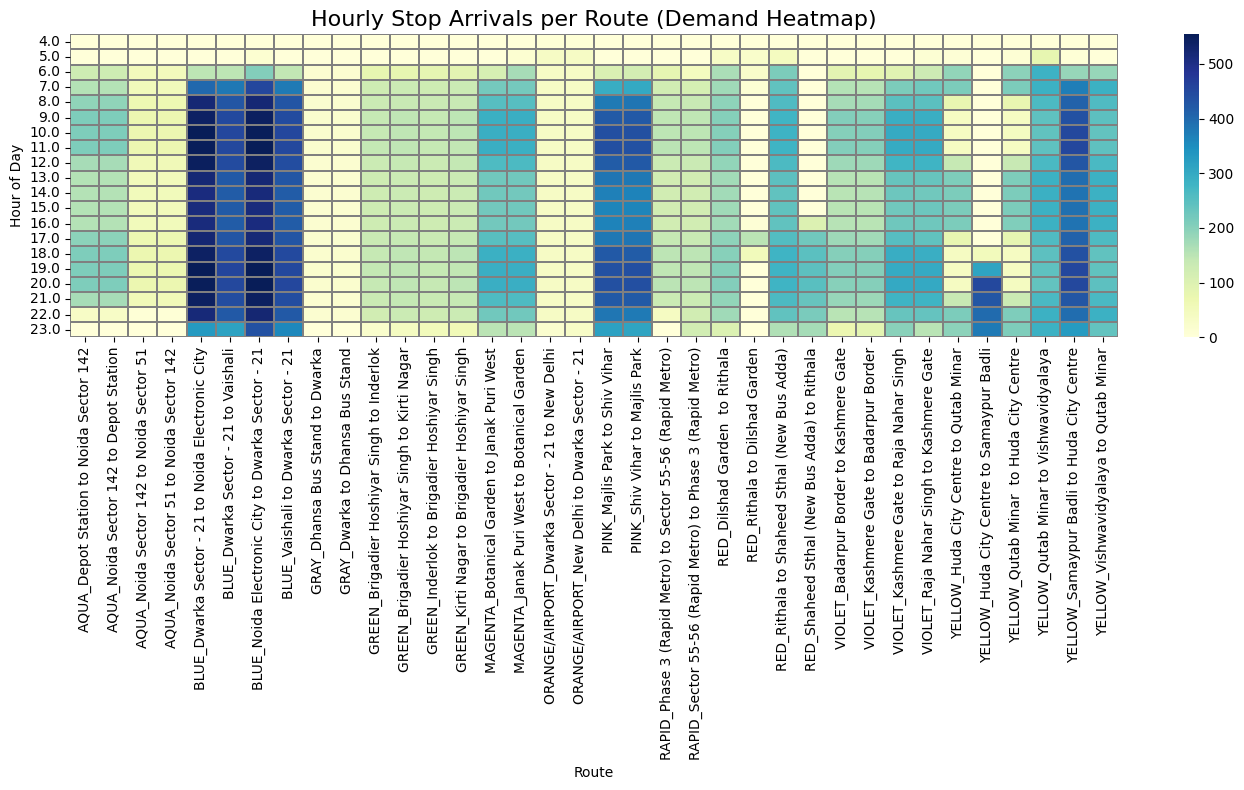

In [54]:

# Count stops by hour per route
hourly_demand = full_df.groupby(['hour', 'route_long_name']).size().unstack(fill_value=0)

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(hourly_demand, cmap='YlGnBu', linewidths=0.3, linecolor='gray')
plt.title("Hourly Stop Arrivals per Route (Demand Heatmap)", fontsize=16)
plt.xlabel("Route")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()



### Hourly Stop visits

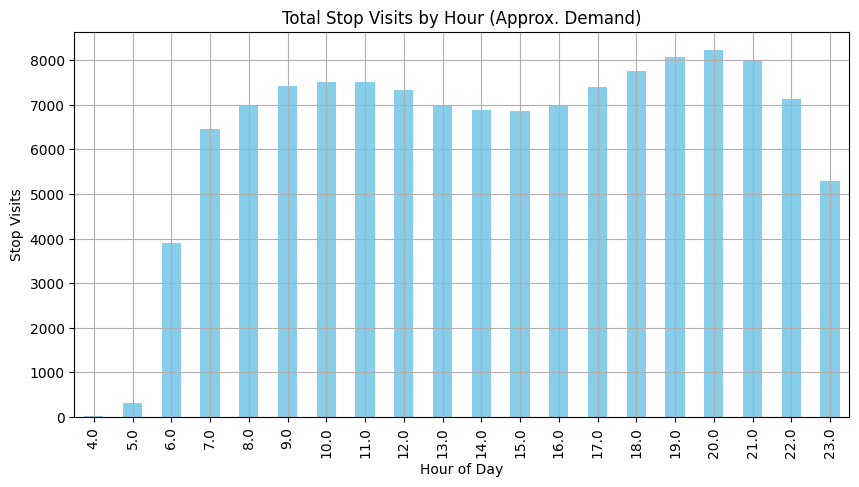

In [ ]:

hourly_total = full_df.groupby('hour').size()
# Plot bar chart
plt.figure(figsize=(10,5))
hourly_total.plot(kind='bar', color='skyblue')
plt.title("Total Stop Visits by Hour (Approx. Demand)")
plt.xlabel("Hour of Day")
plt.ylabel("Stop Visits")
plt.grid(True)
plt.show()


### Doing Analysis of Busiest Metro Stations


Top 10 Busiest Routes (by peak hour stop demand):
route_long_name
BLUE_Dwarka Sector - 21 to Noida Electronic City    554
BLUE_Noida Electronic City to Dwarka Sector - 21    553
BLUE_Dwarka Sector - 21 to Vaishali                 455
YELLOW_Samaypur Badli to Huda City Centre           454
BLUE_Vaishali to Dwarka Sector - 21                 453
YELLOW_Huda City Centre to Samaypur Badli           451
PINK_Shiv Vihar to Majlis Park                      440
PINK_Majlis Park to Shiv Vihar                      440
VIOLET_Kashmere Gate to Raja Nahar Singh            302
VIOLET_Raja Nahar Singh to Kashmere Gate            301
dtype: int64


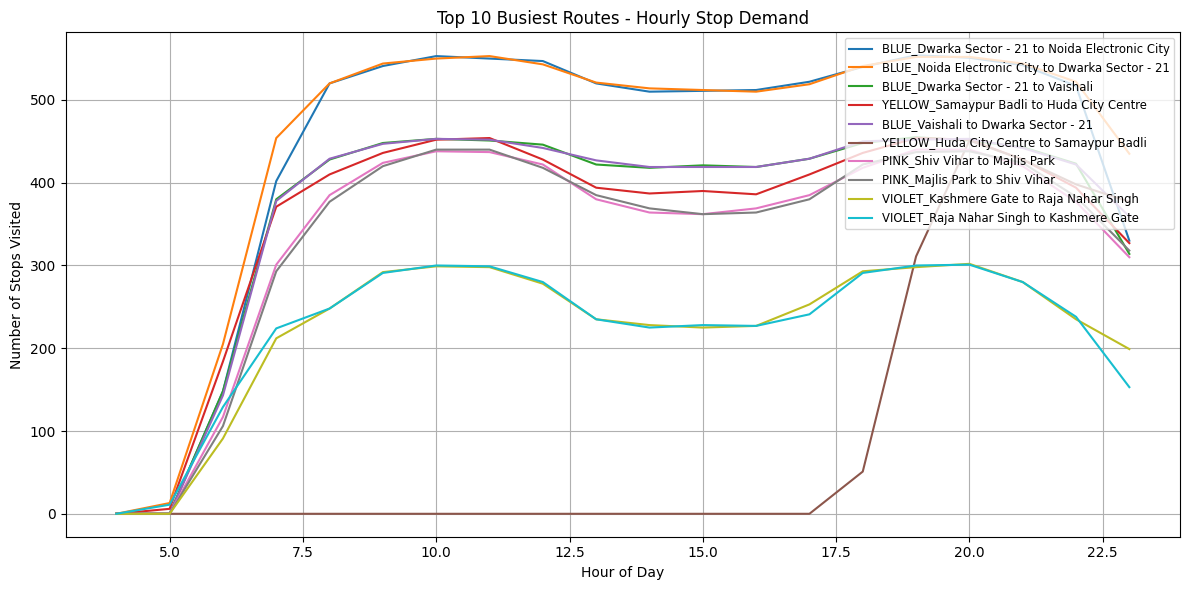

In [56]:
# Create a pivot table of stop visits per route per hour
route_hourly = full_df.groupby(['route_long_name', 'hour']).size().unstack(fill_value=0)

# Identify peak hour demand per route
peak_demand = route_hourly.max(axis=1).sort_values(ascending=False)

# Display top 10 busiest routes (by max hourly demand)
top_busy_routes = peak_demand.head(10)
print("Top 10 Busiest Routes (by peak hour stop demand):")
print(top_busy_routes)

# Visualize
top_routes_df = route_hourly.loc[top_busy_routes.index]

plt.figure(figsize=(12,6))
for route in top_routes_df.index:
    plt.plot(top_routes_df.columns, top_routes_df.loc[route], label=route)

plt.title("Top 10 Busiest Routes - Hourly Stop Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Stops Visited")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()



#### Peaks during 8–10 AM or 5–7 PM = likely overcrowding

#### High max value = high demand pressure on that route

In [ ]:

overcrowded_threshold = 80    
underused_threshold = 10     

# Classify
overcrowded_routes = peak_demand[peak_demand >= overcrowded_threshold].index.tolist()
underutilized_routes = peak_demand[peak_demand <= underused_threshold].index.tolist()

print("\n Suggested for Increased Frequency (Overcrowded):")
for route in overcrowded_routes:
    print(f"➤ {route}")

print("\n Suggested for Reduced Frequency (Underused):")
for route in underutilized_routes:
    print(f"➤ {route}")



 Suggested for Increased Frequency (Overcrowded):
➤ BLUE_Dwarka Sector - 21 to Noida Electronic City
➤ BLUE_Noida Electronic City to Dwarka Sector - 21
➤ BLUE_Dwarka Sector - 21 to Vaishali
➤ YELLOW_Samaypur Badli to Huda City Centre
➤ BLUE_Vaishali to Dwarka Sector - 21
➤ YELLOW_Huda City Centre to Samaypur Badli
➤ PINK_Shiv Vihar to Majlis Park
➤ PINK_Majlis Park to Shiv Vihar
➤ VIOLET_Kashmere Gate to Raja Nahar Singh
➤ VIOLET_Raja Nahar Singh to Kashmere Gate
➤ MAGENTA_Botanical Garden to Janak Puri West
➤ MAGENTA_Janak Puri West to Botanical Garden
➤ YELLOW_Qutab Minar to Vishwavidyalaya
➤ YELLOW_Vishwavidyalaya to Qutab Minar
➤ RED_Rithala to Shaheed Sthal (New Bus Adda)
➤ RED_Shaheed Sthal (New Bus Adda) to Rithala
➤ YELLOW_Huda City Centre to Qutab Minar
➤ YELLOW_Qutab Minar  to Huda City Centre
➤ AQUA_Noida Sector 142 to Depot Station
➤ AQUA_Depot Station to Noida Sector 142
➤ VIOLET_Kashmere Gate to Badarpur Border
➤ RED_Dilshad Garden  to Rithala
➤ VIOLET_Badarpur Border to

### Identifying the routes according to trip volume

Top 10 Routes by Trip Volume:
route_long_name
YELLOW_Qutab Minar to Vishwavidyalaya                        251
YELLOW_Qutab Minar  to Huda City Centre                      239
YELLOW_Vishwavidyalaya to Qutab Minar                        234
YELLOW_Huda City Centre to Qutab Minar                       234
AQUA_Noida Sector 142 to Depot Station                       224
AQUA_Depot Station to Noida Sector 142                       224
YELLOW_Samaypur Badli to Huda City Centre                    197
RAPID_Sector 55-56 (Rapid Metro) to Phase 3 (Rapid Metro)    196
BLUE_Noida Electronic City to Dwarka Sector - 21             186
BLUE_Vaishali to Dwarka Sector - 21                          184
Name: trip_id, dtype: int64


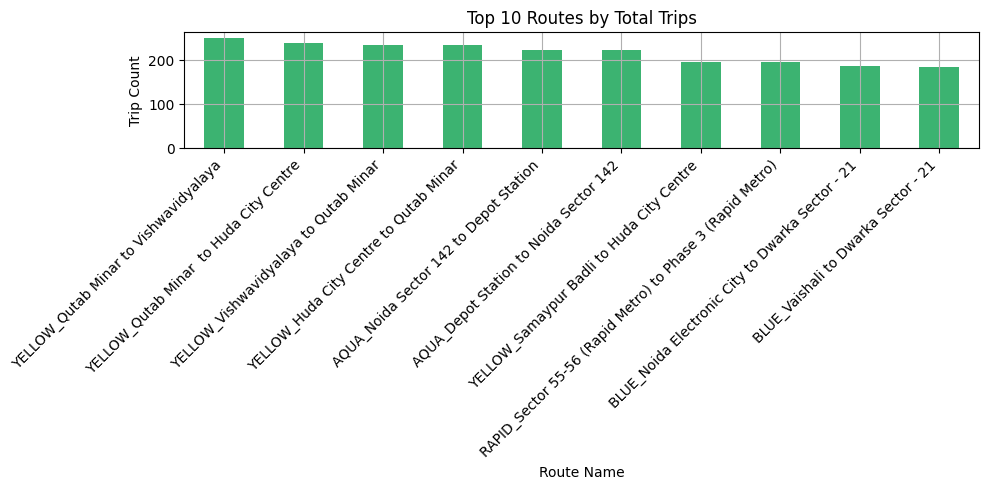

In [ ]:

trips_per_route = full_df.groupby('route_long_name')['trip_id'].nunique().sort_values(ascending=False)

# Display top 10
print("Top 10 Routes by Trip Volume:")
print(trips_per_route.head(10))

# Plot
trips_per_route.head(10).plot(kind='bar', figsize=(10,5), color='mediumseagreen')
plt.title("Top 10 Routes by Total Trips")
plt.ylabel("Trip Count")
plt.xlabel("Route Name")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


### Graph shows uniques stops per route as much data taken in consideration

Routes with Most Stops:
route_long_name
BLUE_Noida Electronic City to Dwarka Sector - 21    50
BLUE_Dwarka Sector - 21 to Noida Electronic City    50
BLUE_Vaishali to Dwarka Sector - 21                 41
BLUE_Dwarka Sector - 21 to Vaishali                 41
PINK_Shiv Vihar to Majlis Park                      38
PINK_Majlis Park to Shiv Vihar                      38
YELLOW_Huda City Centre to Samaypur Badli           37
YELLOW_Samaypur Badli to Huda City Centre           37
VIOLET_Raja Nahar Singh to Kashmere Gate            34
VIOLET_Kashmere Gate to Raja Nahar Singh            34
Name: stop_id, dtype: int64


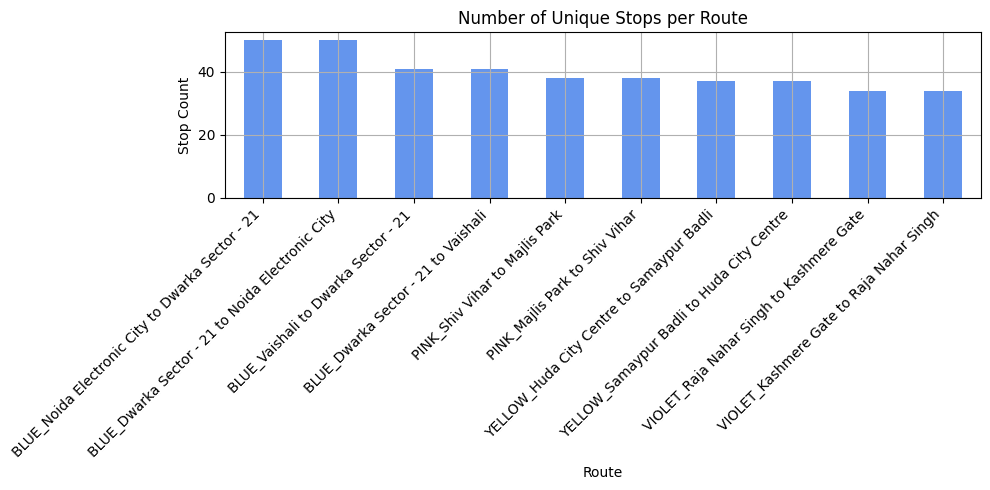

In [59]:
# Count unique stops per route
stops_per_route = full_df.groupby('route_long_name')['stop_id'].nunique().sort_values(ascending=False)

# Display top 10
print("Routes with Most Stops:")
print(stops_per_route.head(10))

# Plot
stops_per_route.head(10).plot(kind='bar', figsize=(10,5), color='cornflowerblue')
plt.title("Number of Unique Stops per Route")
plt.ylabel("Stop Count")
plt.xlabel("Route")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


### Weekday vs Weekend Service Analysis


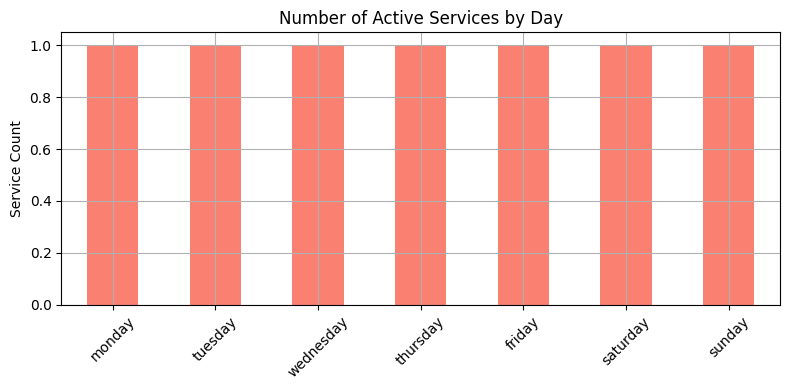

In [ ]:

calendar.head()

# Count services by weekday/weekend
day_columns = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
calendar_sum = calendar[day_columns].sum().sort_values(ascending=False)

# Plot
calendar_sum.plot(kind='bar', figsize=(8,4), color='salmon')
plt.title("Number of Active Services by Day")
plt.ylabel("Service Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### Creating time blocks to see total stop visits per hour

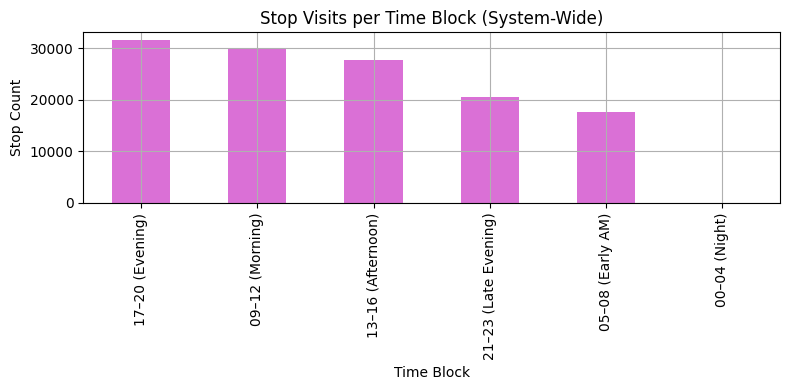

In [ ]:

def time_block(hour):
    if 5 <= hour <= 8: return "05–08 (Early AM)"
    elif 9 <= hour <= 12: return "09–12 (Morning)"
    elif 13 <= hour <= 16: return "13–16 (Afternoon)"
    elif 17 <= hour <= 20: return "17–20 (Evening)"
    elif 21 <= hour <= 23: return "21–23 (Late Evening)"
    else: return "00–04 (Night)"

full_df['time_block'] = full_df['hour'].apply(time_block)

# Total stop visits per block
block_demand = full_df['time_block'].value_counts().sort_values(ascending=False)

# Plot
block_demand.plot(kind='bar', color='orchid', figsize=(8,4))
plt.title("Stop Visits per Time Block (System-Wide)")
plt.xlabel("Time Block")
plt.ylabel("Stop Count")
plt.grid(True)
plt.tight_layout()
plt.show()


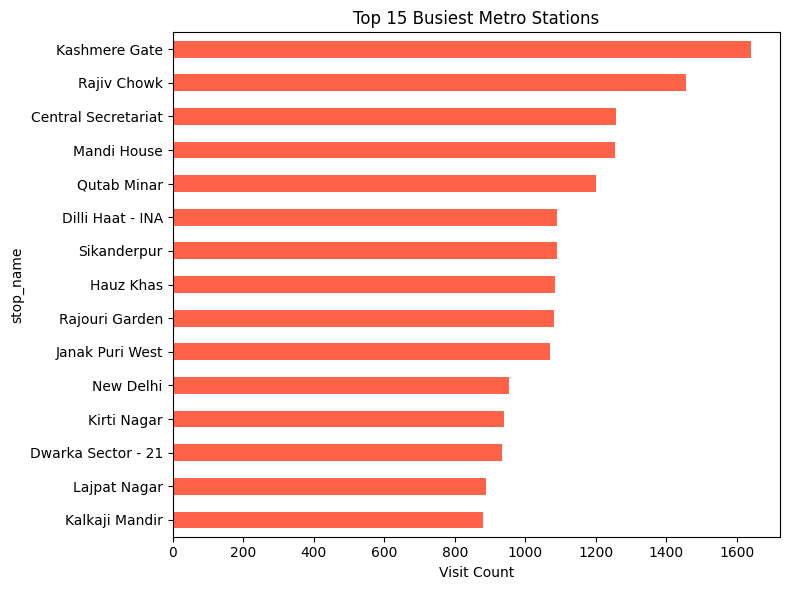

In [62]:
# Count stop visits
busiest_stops = full_df['stop_name'].value_counts().head(15)

# Plot
busiest_stops.plot(kind='barh', figsize=(8,6), color='tomato')
plt.title("Top 15 Busiest Metro Stations")
plt.xlabel("Visit Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Identifying Peak Demand Hours


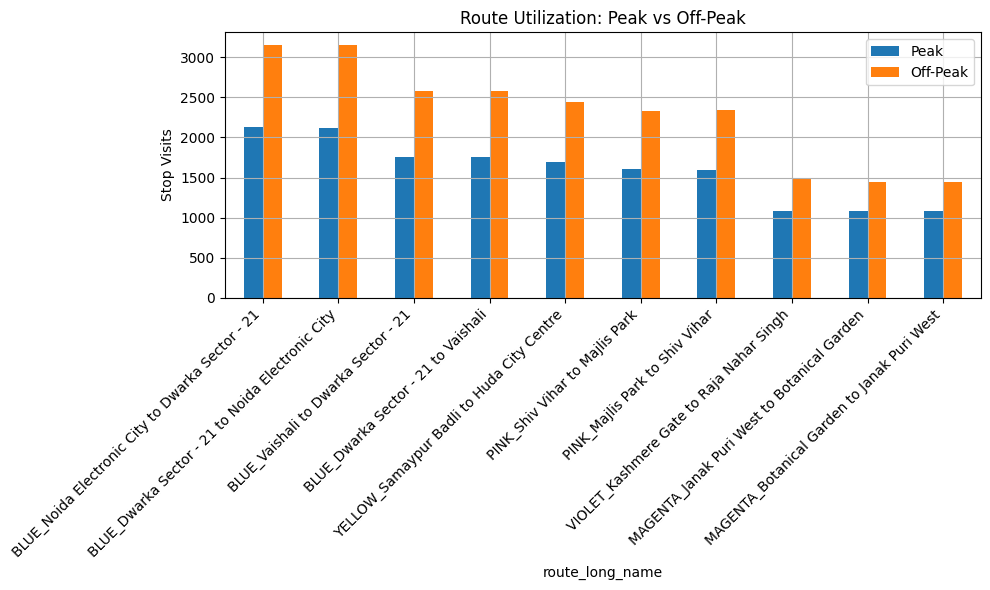

In [63]:
# Define peak (8–10AM, 5–7PM) and off-peak (11AM–4PM)
def peak_type(hour):
    if hour in [8,9,17,18]: return 'Peak'
    elif 11 <= hour <= 16: return 'Off-Peak'
    else: return 'Other'

full_df['peak_category'] = full_df['hour'].apply(peak_type)

# Compare route-level traffic in Peak vs Off-Peak
peak_traffic = full_df[full_df['peak_category'] == 'Peak'].groupby('route_long_name').size()
offpeak_traffic = full_df[full_df['peak_category'] == 'Off-Peak'].groupby('route_long_name').size()

util_compare = pd.DataFrame({
    'Peak': peak_traffic,
    'Off-Peak': offpeak_traffic
}).fillna(0)

# Plot top 10
util_compare.sort_values('Peak', ascending=False).head(10).plot(kind='bar', figsize=(10,6))
plt.title("Route Utilization: Peak vs Off-Peak")
plt.ylabel("Stop Visits")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


Number of Stations per Metro Line

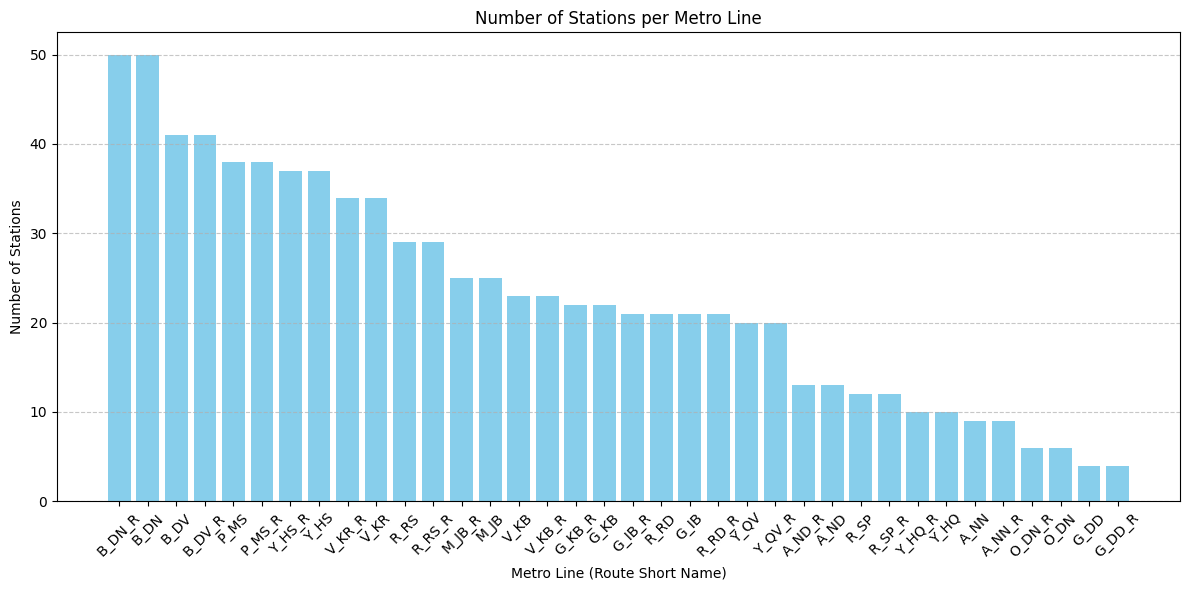

In [ ]:


# Merge to associate stop_times with route_id
trips_routes = trips.merge(routes, on="route_id")
merged = stop_times.merge(trips_routes, on="trip_id")

# Group by route_id and count unique stops
station_counts = merged.groupby("route_id")["stop_id"].nunique().reset_index()
station_counts = station_counts.merge(routes[["route_id", "route_short_name"]], on="route_id")
station_counts = station_counts.sort_values("stop_id", ascending=False)

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(station_counts["route_short_name"], station_counts["stop_id"], color="skyblue")
plt.xlabel("Metro Line (Route Short Name)")
plt.ylabel("Number of Stations")
plt.title("Number of Stations per Metro Line")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
